Simulating J=0.1 ...
  sigma2_final=6.6593, O_pbar_final=6.0418
Simulating J=0.25 ...
  sigma2_final=6.6446, O_pbar_final=6.4468
Simulating J=0.35 ...
  sigma2_final=6.3712, O_pbar_final=8.0485
All done. Plotting ...


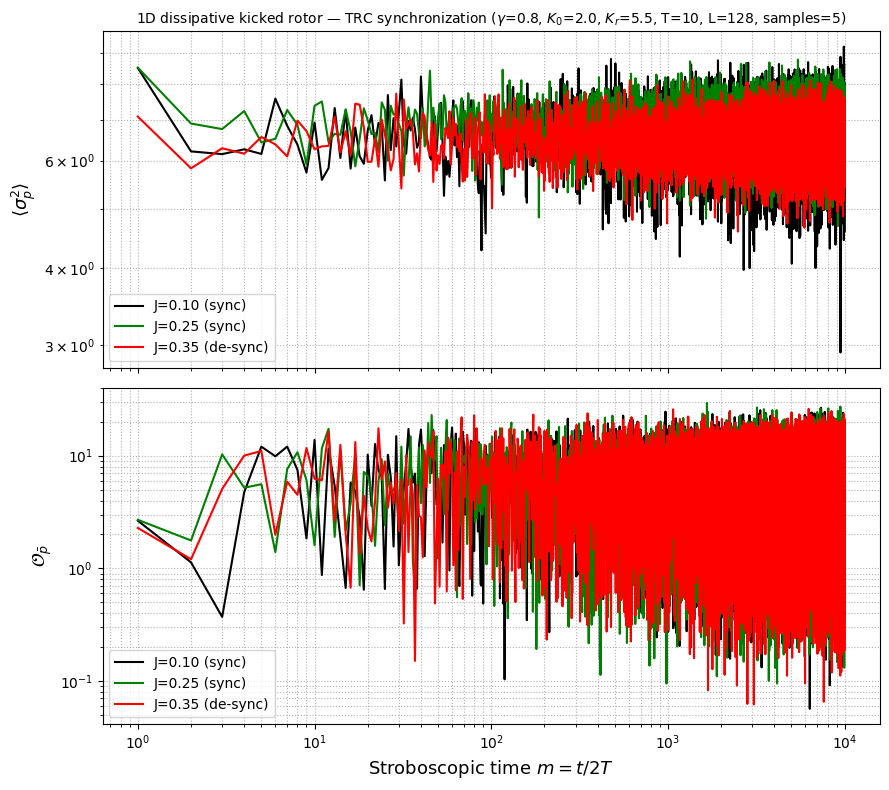

Plot saved.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------
# Parameters
# -----------------------------------------------
L         = 128      # chain length (paper uses 256; reduce for speed)
gamma     = 0.8      # damping coefficient (1-gamma = dissipation rate)
K0        = 2.0      # periodic kick strength
Kr        = 5.5      # random dipolar kick strength
T         = 10       # waiting time between stroboscopic kicks (steps)
J_list    = [0.10, 0.25, 0.35]   # weak/medium -> sync; strong -> de-sync
samples   = 5        # ensemble realizations
n_strobo  = 10000    # stroboscopic periods
                     # each period = 2T deterministic steps + 2 random kicks

P0 = 0.0             # reference fixed point momentum


def single_rotor_step(p, theta, gamma, K0):
    """One deterministic step of the single dissipative rotor (no interaction, no random kick)."""
    p_new     = gamma * p - K0 * np.sin(theta)
    theta_new = (theta + p_new) % (2 * np.pi)
    return p_new, theta_new


def simulate_trc_1d(J, L, gamma, K0, Kr, T, n_strobo, samples):
    """
    Many-body 1D chain with Eq.(3) of Ma et al.:
      p_i(t+1) = gamma*p_i(t) - K0*sin(theta_i) +/- Kr*delta_{t,mT}
                 + J*[sin(theta_i - theta_{i+1}) + sin(theta_i - theta_{i-1})]
      theta_i(t+1) = (theta_i(t) + p_i(t+1)) mod 2pi

    Dipolar kick protocol:
      At each stroboscopic period, randomly choose (+Kr,-Kr) or (-Kr,+Kr).
      Between each kick, evolve the system for T deterministic steps.

    """
    sigma2_accum = np.zeros(n_strobo)
    O_pbar_accum = np.zeros(n_strobo)

    for s in range(samples):
        # Initial conditions

        theta   = np.random.uniform(0, 2 * np.pi, L)
        p       = np.random.normal(0.0, 6.0, L)

        # Reference single-rotor starting at fixed point P0
        p_ref, theta_ref = P0, 0.0

        for m in range(n_strobo):

            if np.random.rand() < 0.5:
                kicks = [+Kr, -Kr]
            else:
                kicks = [-Kr, +Kr]

            for kick in kicks:
                # 1. Apply random kick to many-body system
                p = p + kick

                # 2. Apply same random kick to reference single rotor
                p_ref = p_ref + kick

                # 3. Evolve many-body system for T deterministic steps
                for _ in range(T):
                    theta_right = np.roll(theta, -1)   # theta_{i+1}
                    theta_left  = np.roll(theta,  1)   # theta_{i-1}
                    p = (gamma * p
                         - K0 * np.sin(theta)
                         + J  * (np.sin(theta - theta_right)
                                + np.sin(theta - theta_left)))
                    theta = (theta + p) % (2 * np.pi)

                # 4. Evolve reference single rotor for T deterministic steps
                for _ in range(T):
                    p_ref, theta_ref = single_rotor_step(p_ref, theta_ref, gamma, K0)

            # --- Record at stroboscopic time 2mT ---
            p_bar = np.mean(p)
            sigma2_accum[m] += np.mean((p - p_bar)**2)
            O_pbar_accum[m] += (p_bar - p_ref)**2

    return sigma2_accum / samples, O_pbar_accum / samples


# -----------------------------------------------
# Run for each J value
# -----------------------------------------------
strobo_times = np.arange(1, n_strobo + 1)
results = {}

for J in J_list:
    print(f"Simulating J={J} ...")
    sigma2, O_pbar = simulate_trc_1d(J, L, gamma, K0, Kr, T, n_strobo, samples)
    results[J] = (sigma2, O_pbar)
    print(f"  sigma2_final={sigma2[-50:].mean():.4f}, O_pbar_final={O_pbar[-50:].mean():.4f}")

print("All done. Plotting ...")

# -----------------------------------------------
# Plotting
# -----------------------------------------------
colors = {0.10: "black", 0.25: "green", 0.35: "red"}
labels = {0.10: "J=0.10 (sync)",
          0.25: "J=0.25 (sync)",
          0.35: "J=0.35 (de-sync)"}

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for J in J_list:
    sigma2, O_pbar = results[J]
    axes[0].plot(strobo_times, sigma2,  color=colors[J], label=labels[J])
    axes[1].plot(strobo_times, O_pbar, color=colors[J], label=labels[J])

# Top panel: momentum variance
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_ylabel(r"$\langle \sigma^2_p \rangle$", fontsize=13)
axes[0].set_title(
    rf"1D dissipative kicked rotor — TRC synchronization"
    rf" ($\gamma$={gamma}, $K_0$={K0}, $K_r$={Kr}, T={T}, L={L}, samples={samples})",
    fontsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(True, which="both", ls=":")

# Bottom panel: TRC order parameter
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"Stroboscopic time $m = t/2T$", fontsize=13)
axes[1].set_ylabel(r"$\mathcal{O}_{\bar{p}}$", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, which="both", ls=":")

plt.tight_layout()
plt.savefig("trc_sync_1d_plot.png", dpi=150)
plt.show()
print("Plot saved.")